In [4]:
#Importing Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 


In [ ]:
#importing file and printing head and columns of data
db = pd.read_csv("WB_WDI_SP_POP_GROW.csv")
#print(db.head())
print(db.columns)


       STRUCTURE                STRUCTURE_ID ACTION FREQ REF_AREA  \
0  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      UZB   
1  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      VUT   
2  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      VEN   
3  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      VNM   
4  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      VIR   

            INDICATOR SEX AGE URBANISATION UNIT_MEASURE  ...  \
0  WB_WDI_SP_POP_GROW  _T  _T           _T         PC_A  ...   
1  WB_WDI_SP_POP_GROW  _T  _T           _T         PC_A  ...   
2  WB_WDI_SP_POP_GROW  _T  _T           _T         PC_A  ...   
3  WB_WDI_SP_POP_GROW  _T  _T           _T         PC_A  ...   
4  WB_WDI_SP_POP_GROW  _T  _T           _T         PC_A  ...   

  COMP_BREAKDOWN_2_LABEL COMP_BREAKDOWN_3_LABEL AGG_METHOD_LABEL  \
0         Not Applicable         Not Applicable   Not Applicable   
1         Not Applicable         Not Applicable   Not Applicable

In [ ]:
''' Selecting useful columns  
where REF_AREA=>Countries code (categorical data)
TIME_PRIOD=> Year of recording data
OBS_Value=> Population Growth data (continuous data)
'''
df=db[["REF_AREA","TIME_PERIOD","OBS_VALUE"]]
print(df.head())

  REF_AREA  TIME_PERIOD  OBS_VALUE
0      UZB         1999   1.403325
1      VUT         1999   2.072996
2      VEN         1999   1.952133
3      VNM         1999   1.303285
4      VIR         1999   0.057107


In [ ]:
#Grouping continuous and Categorical data and find the average of data so data cant get too messy 
avg_growth = df.groupby("REF_AREA")["OBS_VALUE"].mean().reset_index()
top10 = avg_growth.sort_values(by="OBS_VALUE", ascending=False).head(10)

In [45]:
#Printing head of top 10 data 
print("",top10.head())

     REF_AREA  OBS_VALUE
8        ARE   6.916671
199      QAT   6.834404
224      SXM   4.328929
126      KWT   4.306947
204      SAU   4.177779


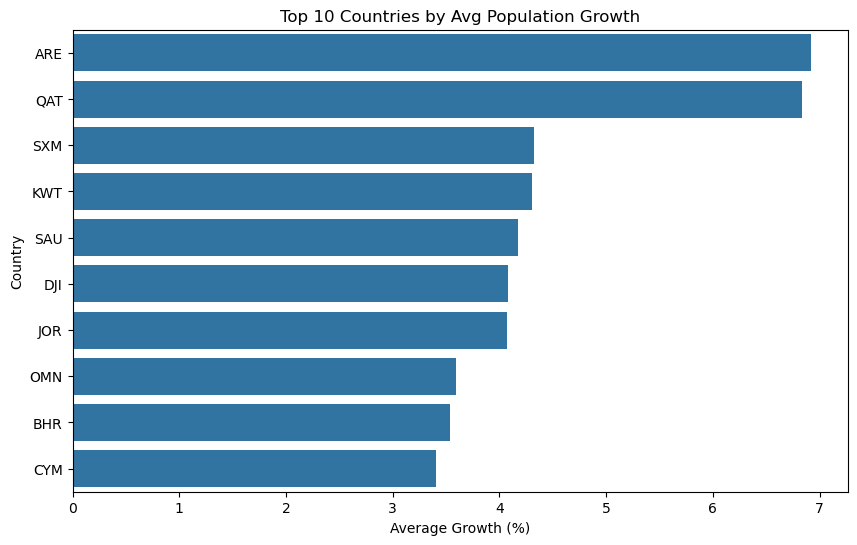

In [ ]:
#Barplot of Top 10 countries AVG population growth
plt.figure(figsize=(10,6))
sns.barplot(x='OBS_VALUE', y='REF_AREA', data=top10)
plt.title("Top 10 Countries by Avg Population Growth")
plt.xlabel("Average Growth (%)")
plt.ylabel("Country")
plt.show()

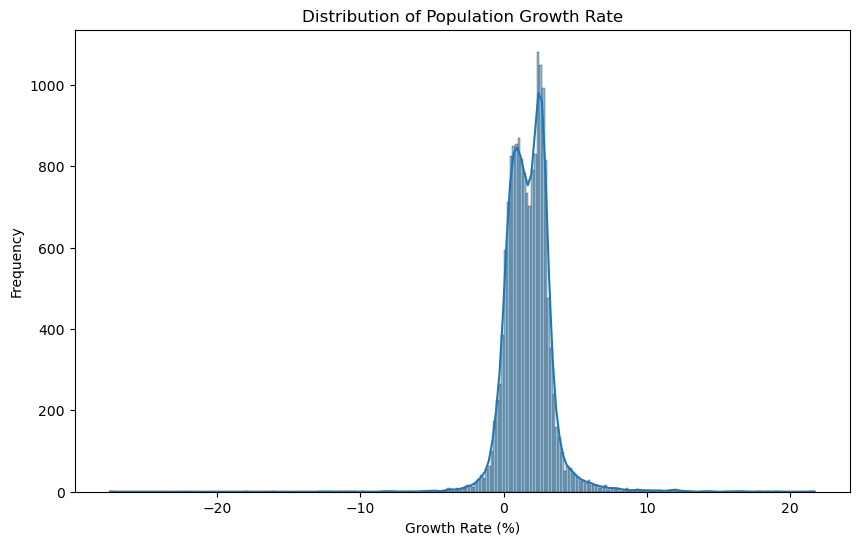

In [9]:
#Histplot 

plt.figure(figsize=(10,6))
sns.histplot(df['OBS_VALUE'],kde=True)
plt.title("Distribution of Population Growth Rate")
plt.xlabel("Growth Rate (%)")
plt.ylabel("Frequency")
plt.show()